# Modelo estructural de series temporales: Prophet

Prophet es el modelo **central** de este TFM. Aborda el pronóstico descomponiendo la serie en
componentes interpretables en lugar de explotar su autocorrelación. Se compara contra las dos
referencias que el cuaderno econométrico dejó guardadas en `Resultados/`, el suelo de paseo aleatorio
y el benchmark ARIMA.

## Cómo funciona Prophet

Prophet modela una serie como la suma de una tendencia `g(t)`, una estacionalidad `s(t)`, el efecto de
eventos puntuales `h(t)` y un error. La tendencia es una recta partida en tramos por **changepoints**,
puntos donde la pendiente puede cambiar; su flexibilidad, gobernada por `changepoint_prior_scale`, es
el hiperparámetro más decisivo. La estacionalidad se modela con series de Fourier y los eventos, los
holidays, recogen aquí el shock de la COVID en 2020-Q2.

A diferencia de un modelo ARIMA, Prophet **no tiene componente autorregresivo**: no ancla el
pronóstico al último valor observado, sino que extrapola la tendencia estimada. Para una serie tan
persistente como el paro esto es una limitación de fondo, y es el eje de este cuaderno.

## Dos formas de la serie, ancladas en el EDA

El EDA caracterizó la tasa de paro como estacionaria en nivel, I(0), **sin estacionalidad relevante** y
con la diferencia interanual disponible como forma estacionaria alternativa. A partir de ahí se
modelan y comparan **dos formas**:

- **En nivel** (la forma natural de Prophet, la que fija el EDA): Prophet modela la tasa directamente.
- **En diferencia (diff1) reconstruida**: Prophet modela el cambio intertrimestral y el pronóstico se
  reconstruye acumulando desde el último valor observado. Esta integración le da a Prophet el
  **anclaje** que su tendencia no aporta, y es la vía para que compita en una serie persistente.

Cada forma se optimiza con una búsqueda exhaustiva de hiperparámetros y se guarda por separado. La
comparación entre ambas es uno de los resultados del cuaderno.

## 1. Datos y configuración

Se consume `Datasets Modelado/prophet_nivel_modelado.csv`, el panel completo con el objetivo en nivel
(renombrado a `y`). Configuración anclada en el EDA: sin estacionalidad de partida (el target no la
tiene; la búsqueda puede reactivarla si los datos lo justifican) y el holiday de la COVID en 2020-Q2.

In [7]:
import json
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from prophet import Prophet

warnings.filterwarnings("ignore")
for _n in ("prophet", "cmdstanpy"):
    logging.getLogger(_n).setLevel(logging.ERROR)
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_style("whitegrid")

RAIZ = Path.cwd().parent if Path.cwd().name == "Modelos" else Path.cwd()
RUTA_DATOS = RAIZ / "Datasets Modelado" / "prophet_nivel_modelado.csv"
RUTA_RESULTADOS = RAIZ / "Resultados"
RUTA_RESULTADOS.mkdir(exist_ok=True)

HORIZONTES = [0, 1, 2, 3, 4]
PRIMER_TEST = "1996Q1"
RANGO_PLAUSIBLE = (0.0, 60.0)
MARGEN_SALTO = 2.0
N_TRIALS = 40                          # trials de Optuna por forma (busqueda exhaustiva)
VAL_INI, VAL_FIN = "1989Q1", "1994Q4"  # validacion temporal interna, anterior al test (sin fuga)

C = {"real": "#1f2a44", "rw": "#9aa6b2", "arima": "#2e7d32", "nivel": "#c2185b", "diff1": "#6a1b9a",
     "band": "#6a1b9a", "corte": "#78909C"}

In [8]:
df = pd.read_csv(RUTA_DATOS, parse_dates=["fecha"]).sort_values("fecha").reset_index(drop=True)
y = df["y"]
fechas = df["fecha"]
N = len(df)

# Holiday de la COVID: 2020-Q2 como evento puntual conocido
HOLIDAYS = pd.DataFrame({"holiday": "covid_2020q2", "ds": [pd.Timestamp("2020-04-01")],
                         "lower_window": 0, "upper_window": 0})

def _idx(q):
    return int(df.index[df["fecha"] == pd.Period(q, "Q").to_timestamp()][0])

PRIMER_TAU = _idx(PRIMER_TEST)
FOLDS = [t for t in range(PRIMER_TAU, N) if t + max(HORIZONTES) <= N - 1]
VAL = list(range(_idx(VAL_INI), _idx(VAL_FIN) + 1))
print(f"Observaciones: {N}  |  rango: {fechas.iloc[0].date()} a {fechas.iloc[-1].date()}")
print(f"Test: {fechas.iloc[FOLDS[0]].date()} a {fechas.iloc[FOLDS[-1]].date()} ({len(FOLDS)} folds)")
print(f"Validación interna (tuning, sin fuga): {fechas.iloc[VAL[0]].date()} a {fechas.iloc[VAL[-1]].date()} ({len(VAL)} orígenes)")

Observaciones: 198  |  rango: 1976-07-01 a 2025-10-01
Test: 1996-01-01 a 2024-10-01 (116 folds)
Validación interna (tuning, sin fuga): 1989-01-01 a 1994-10-01 (24 orígenes)


## 2. Validación común y referencias

Mismo esquema del cuaderno econométrico: expanding window, los mismos 116 folds, horizontes nowcast a
+4 y la misma guarda de estabilidad. El suelo de paseo aleatorio y el benchmark ARIMA se cargan de
`Resultados/`.

In [9]:
def _rmse(e):
    """Raíz del error cuadrático medio."""
    return float(np.sqrt(np.mean(np.square(e)))) if len(e) else float("nan")


def _mae(e):
    """Error absoluto medio."""
    return float(np.mean(np.abs(e))) if len(e) else float("nan")


def cota_salto(endog, h_max, margen=MARGEN_SALTO):
    """Cota por horizonte del salto admisible respecto al último valor (calibrada solo con train)."""
    arr = np.asarray(endog)
    return [margen * float(np.nanmax(np.abs(arr[h + 1:] - arr[:-(h + 1)]))) if len(arr) > h + 1 else np.inf
            for h in range(h_max + 1)]


def es_inestable(pred, ultimo, cota):
    """True si el pronóstico es no finito, fuera de rango plausible o salta más que la cota."""
    return (not np.isfinite(pred) or pred < RANGO_PLAUSIBLE[0] or pred > RANGO_PLAUSIBLE[1]
            or abs(pred - ultimo) > cota)


def metricas_desde_preds(preds, rmse_ref=None, rmse_bench=None):
    """RMSE y MAE por horizonte, global y subperiodo COVID, con skill frente a RW y ARIMA."""
    out = {"por_horizonte": {}, "global": {}, "covid": {}}
    err = preds["y_real"] - preds["y_pred"]
    es_covid = preds["fecha"].astype(str).str.match(r"20(20|21)Q")
    for h in sorted(preds["horizonte"].unique()):
        m = preds["horizonte"] == h
        d = {"rmse": _rmse(err[m].to_numpy()), "mae": _mae(err[m].to_numpy()), "n": int(m.sum())}
        if rmse_ref and rmse_ref.get(h):
            d["skill_vs_rw"] = float(1 - d["rmse"] / rmse_ref[h])
        if rmse_bench and rmse_bench.get(h):
            d["skill_vs_arima"] = float(1 - d["rmse"] / rmse_bench[h])
        out["por_horizonte"][str(h)] = d
        mc = m & es_covid
        out["covid"][str(h)] = {"rmse": _rmse(err[mc].to_numpy()), "mae": _mae(err[mc].to_numpy()),
                                "n": int(mc.sum())}
    out["global"] = {"rmse": _rmse(err.to_numpy()), "mae": _mae(err.to_numpy()), "n": int(len(err))}
    return out


def guardar(modelo, preds, metricas):
    """Escribe en Resultados/ las predicciones y métricas del modelo."""
    preds.to_csv(RUTA_RESULTADOS / f"preds_{modelo}.csv", index=False)
    with open(RUTA_RESULTADOS / f"metricas_{modelo}.json", "w", encoding="utf-8") as f:
        json.dump(metricas, f, ensure_ascii=False, indent=2)


def tabla_horizontes(met):
    """Resumen por horizonte de RMSE, MAE, skill frente a RW y ARIMA, y RMSE-COVID."""
    filas = []
    for h in HORIZONTES:
        d = met["por_horizonte"][str(h)]
        filas.append({"horizonte": h, "rmse": round(d["rmse"], 4), "mae": round(d["mae"], 4),
                      "skill_vs_rw": round(d.get("skill_vs_rw", float("nan")), 3),
                      "skill_vs_arima": round(d.get("skill_vs_arima", float("nan")), 3),
                      "covid_rmse": round(met["covid"][str(h)]["rmse"], 4)})
    return pd.DataFrame(filas).set_index("horizonte")


preds_rw = pd.read_csv(RUTA_RESULTADOS / "preds_random_walk.csv")
preds_ar = pd.read_csv(RUTA_RESULTADOS / "preds_arima.csv")
RMSE_RW = {h: _rmse((preds_rw[preds_rw.horizonte == h].eval("y_real - y_pred")).to_numpy()) for h in HORIZONTES}
RMSE_AR = {h: _rmse((preds_ar[preds_ar.horizonte == h].eval("y_real - y_pred")).to_numpy()) for h in HORIZONTES}
print("Referencias (RMSE global):  RW", round(_rmse((preds_rw.y_real - preds_rw.y_pred).to_numpy()), 3),
      " ARIMA", round(_rmse((preds_ar.y_real - preds_ar.y_pred).to_numpy()), 3))

Referencias (RMSE global):  RW 1.883  ARIMA 1.531


In [10]:
# Funciones de grafico reutilizables (mismas que en NB1/NB3, homogeneas entre notebooks)
PRIMER_TS = fechas.iloc[FOLDS[0]]                       # frontera entrenamiento / test (Timestamp)


def plot_backtest(preds, nombre, color):
    """Backtest del nowcast sobre el historico completo: entrenamiento sombreado, test con prediccion y banda de error empirica."""
    s = preds[preds["horizonte"] == 0].sort_values("fecha")
    ejex = pd.PeriodIndex(s["fecha"].values, freq="Q").to_timestamp()
    pred = s["y_pred"].to_numpy(); resid = (s["y_real"] - s["y_pred"]).to_numpy()
    rmse = _rmse(resid)
    sigma = pd.Series(resid).rolling(8, min_periods=3).std().bfill().to_numpy()  # volatilidad local (regime-aware)
    fig, ax = plt.subplots(figsize=(14, 4.8))
    ax.axvspan(fechas.iloc[0], PRIMER_TS, color="0.5", alpha=0.07)                 # entrenamiento (sin prediccion OOS)
    ax.plot(fechas, y.values, color=C["real"], lw=1.7, label="Real", zorder=3)     # serie completa
    ax.fill_between(ejex, pred - 1.96 * sigma, pred + 1.96 * sigma, color=color,    # banda de error al 95% (gaussiana sobre residuos)
                    alpha=0.18, label="banda de error 95% (volatilidad local)")
    ax.plot(ejex, pred, color=color, lw=1.5, ls="--", label=f"{nombre} (nowcast OOS)", zorder=4)
    ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2021-12-31"), color="red", alpha=0.06)  # COVID
    ax.text(fechas.iloc[0], y.max() * 0.99, "  entrenamiento", color="0.4", fontsize=8.5, va="top")
    ax.text(PRIMER_TS, y.max() * 0.99, "  test (1996-2024)", color="0.4", fontsize=8.5, va="top")
    ax.set_title(f"Backtest del nowcast: {nombre}   |   RMSE OOS = {rmse:.3f}", fontsize=12, fontweight="bold")
    ax.set_ylabel("tasa de paro (%)"); ax.set_xlabel(""); ax.legend(fontsize=8.5, loc="upper right", ncol=2)
    plt.tight_layout(); plt.show()


def plot_rmse_horizonte(modelos):
    """RMSE por horizonte de varios modelos en un unico grafico a ancho completo (la comparacion aporta aqui)."""
    fig, ax = plt.subplots(figsize=(14, 4.5))
    for nombre, met, color in modelos:
        ax.plot(HORIZONTES, [met["por_horizonte"][str(h)]["rmse"] for h in HORIZONTES],
                marker="o", lw=2, label=nombre, color=color)
    ax.set_xlabel("horizonte (0 = nowcast, 4 = un ano vista)"); ax.set_ylabel("RMSE (puntos de paro)")
    ax.set_xticks(HORIZONTES); ax.set_title("RMSE por horizonte de pronostico", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9); plt.tight_layout(); plt.show()


def plot_errores(modelos, horizonte=0):
    """Error de pronostico en el tiempo (real - prediccion, OOS): muestra donde falla cada modelo y que los errores son reales (no hay sobreajuste)."""
    fig, ax = plt.subplots(figsize=(14, 4.5))
    base = modelos[0][1]
    s0 = base[base["horizonte"] == horizonte].sort_values("fecha")
    ejex = pd.PeriodIndex(s0["fecha"].values, freq="Q").to_timestamp()
    ax.axhline(0, color="0.5", lw=1)
    ax.axvspan(pd.Timestamp("2008-07-01"), pd.Timestamp("2009-07-01"), color="grey", alpha=0.08)   # crisis 2008
    ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2021-12-31"), color="red", alpha=0.07)     # COVID
    for nombre, preds, color in modelos:
        s = preds[preds["horizonte"] == horizonte].sort_values("fecha")
        err = (s["y_real"] - s["y_pred"]).to_numpy()
        ax.plot(ejex, err, color=color, lw=1.3, alpha=0.9, label=f"{nombre} (RMSE {_rmse(err):.2f})")
    ax.set_title("Error de pronostico en el tiempo (real - prediccion, nowcast OOS)", fontsize=12, fontweight="bold")
    ax.set_ylabel("error (puntos de paro)"); ax.set_xlabel(""); ax.legend(fontsize=9, ncol=len(modelos), loc="lower left")
    plt.tight_layout(); plt.show()

## 3. Búsqueda exhaustiva de hiperparámetros

La misma maquinaria sirve para las dos formas. El espacio de búsqueda recorre todos los
hiperparámetros relevantes de Prophet:

- `changepoint_prior_scale`, la flexibilidad de la tendencia, el decisivo, de 0.001 a 0.9.
- `changepoint_range`, hasta qué punto de la muestra se permiten quiebres, de 0.8 a 0.95.
- `n_changepoints`, número de quiebres potenciales, de 5 a 35.
- `holidays_prior_scale`, efecto del holiday de la COVID, de 0.01 a 10.
- orden de Fourier de la estacionalidad anual, de 0 a 3, donde 0 la desactiva. Se deja que la propia
  búsqueda confirme el hallazgo del EDA de que la estacionalidad no aporta.

La optimización es bayesiana con Optuna. Cada configuración se evalúa por su RMSE multihorizonte en una
**validación temporal interna** sobre 1989-1995, anterior al test, de modo que no hay fuga. La misma
búsqueda se aplica a la forma en nivel y a la forma en diferencia.

In [11]:
def construir_serie(forma):
    """Serie que modela Prophet: el nivel, o el cambio intertrimestral (diff1)."""
    return y.copy() if forma == "nivel" else y.diff(1)


def fit_prophet(serie_df, hp):
    """Ajusta un Prophet con los HP dados; activa estacionalidad anual solo si Fourier > 0."""
    kw = dict(weekly_seasonality=False, daily_seasonality=False, holidays=HOLIDAYS,
              changepoint_prior_scale=hp["cps"], changepoint_range=hp["cr"],
              n_changepoints=hp["n_cp"], holidays_prior_scale=hp["hps"],
              yearly_seasonality=(hp["fourier"] if hp["fourier"] > 0 else False))
    if hp["fourier"] > 0:
        kw["seasonality_prior_scale"] = hp["sps"]
    m = Prophet(**kw)
    m.fit(serie_df[["ds", "y"]])
    return m


def pronostico(tau, hp, forma, h_max=4):
    """Pronóstico nowcast..+h_max desde el origen tau. En diff1 se reconstruye acumulando el cambio."""
    ult = float(y.iloc[tau - 1])
    serie = construir_serie(forma)
    sdf = pd.DataFrame({"ds": fechas, "y": serie}).iloc[:tau].dropna()
    try:
        m = fit_prophet(sdf, hp)
        fc = m.predict(m.make_future_dataframe(periods=h_max + 1, freq="QS"))["yhat"].to_numpy()[-(h_max + 1):]
    except Exception:
        fc = np.repeat(0.0 if forma == "diff1" else ult, h_max + 1)
    if forma == "nivel":
        return fc
    out, prev = [], ult                                  # diff1: y_{t+h} = y_{t-1} + cambios acumulados
    for h in range(h_max + 1):
        prev = prev + fc[h]
        out.append(prev)
    return np.array(out)


def espacio_hp(trial):
    """Configuración muestreada del espacio de búsqueda de Prophet."""
    f = trial.suggest_int("fourier", 0, 3)
    hp = {"cps": trial.suggest_float("cps", 0.001, 0.9, log=True),
          "cr": trial.suggest_float("cr", 0.80, 0.95),
          "n_cp": trial.suggest_int("n_cp", 5, 35),
          "hps": trial.suggest_float("hps", 0.01, 10.0, log=True),
          "fourier": f,
          "sps": trial.suggest_float("sps", 0.01, 10.0, log=True) if f > 0 else 1.0}
    return hp


def evaluar_hp(hp, forma, origenes):
    """RMSE multihorizonte de una configuración sobre orígenes de validación, con guarda, sin fuga."""
    err = []
    for tau in origenes:
        arr = y.iloc[:tau].to_numpy(); ult = float(arr[-1]); cotas = cota_salto(arr, max(HORIZONTES))
        fc = pronostico(tau, hp, forma)
        for h in HORIZONTES:
            p = ult if es_inestable(fc[h], ult, cotas[h]) else float(fc[h])
            err.append(float(y.iloc[tau + h]) - p)
    return _rmse(np.array(err))


def buscar_hp(forma, n_trials=N_TRIALS):
    """Búsqueda Optuna de hiperparámetros para una forma, sobre la validación interna (sin fuga)."""
    est = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
    est.optimize(lambda tr: evaluar_hp(espacio_hp(tr), forma, VAL), n_trials=n_trials, show_progress_bar=False)
    return est


def backtest(forma, hp):
    """Expanding window completo de una forma con los HP dados; un ajuste por fold."""
    filas, guardas = [], 0
    for fold, tau in enumerate(FOLDS):
        arr = y.iloc[:tau].to_numpy(); ult = float(arr[-1]); cotas = cota_salto(arr, max(HORIZONTES))
        fc = pronostico(tau, hp, forma)
        disparo = False
        for h in HORIZONTES:
            p = float(fc[h])
            if es_inestable(p, ult, cotas[h]):
                p = ult; disparo = True
            filas.append({"fecha": str(fechas.iloc[tau + h].to_period("Q")), "y_real": float(y.iloc[tau + h]),
                          "y_pred": p, "horizonte": h, "fold": fold})
        guardas += int(disparo)
    print(f"[{forma}] guardas de estabilidad activadas: {guardas}/{len(FOLDS)}")
    return pd.DataFrame(filas)


def tabla_trials(est, top=10):
    """Trials de Optuna rankeados por RMSE de validación (la búsqueda, visible)."""
    cols = {"value": "rmse_val", "params_cps": "cps", "params_cr": "cr", "params_n_cp": "n_cp",
            "params_hps": "hps", "params_fourier": "fourier"}
    t = est.trials_dataframe()
    t = t[[c for c in cols if c in t.columns]].rename(columns=cols)
    return t.sort_values("rmse_val").round(4).head(top).reset_index(drop=True)

## 4. Forma en nivel (configuración base del EDA)

Prophet modela la tasa de paro directamente en nivel, la forma que el EDA fija como natural. Se ejecuta
la búsqueda exhaustiva y se evalúa en el expanding window. El resultado se guarda como `prophet_nivel`.

In [12]:
est_nivel = buscar_hp("nivel")
HP_NIVEL = est_nivel.best_params
print("mejores HP (nivel):", {k: (round(v, 4) if isinstance(v, float) else v) for k, v in HP_NIVEL.items()})
tabla_trials(est_nivel)

mejores HP (nivel): {'fourier': 2, 'cps': 0.0018, 'cr': 0.8657, 'n_cp': 13, 'hps': 0.0793, 'sps': 0.3565}


,rmse_val,cps,cr,n_cp,hps,fourier
0,1.1647,0.0018,0.8657,13,0.0793,2
1,1.1647,0.0017,0.8645,13,0.0129,2
2,1.1662,0.0023,0.8357,9,0.0109,2
3,1.1663,0.0020,0.8357,10,0.0104,2
4,1.1665,0.0017,0.8409,13,0.0147,2
5,1.1673,0.0015,0.8666,14,0.0636,2
6,1.1685,0.0011,0.8441,12,0.0182,2
7,1.1715,0.0015,0.8618,13,0.0574,2
8,1.1721,0.0024,0.8335,7,0.0204,2
9,1.1780,0.0021,0.8145,19,0.0122,3


In [13]:
preds_nivel = backtest("nivel", HP_NIVEL)
met_nivel = metricas_desde_preds(preds_nivel, RMSE_RW, RMSE_AR)
met_nivel["referencia_rw"] = {str(h): RMSE_RW[h] for h in HORIZONTES}
met_nivel["benchmark_arima"] = {str(h): RMSE_AR[h] for h in HORIZONTES}
met_nivel["hiperparametros"] = {k: (round(v, 5) if isinstance(v, float) else v) for k, v in HP_NIVEL.items()}
guardar("prophet_nivel", preds_nivel, met_nivel)
tabla_horizontes(met_nivel)

23:03:40 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:03:40 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:03:40 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:03:40 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:03:41 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:03:41 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:03:41 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:03:41 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:03:42 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:03:42 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:03:42 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:03:42 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:03:42 - cmdstanpy - ERROR

[nivel] guardas de estabilidad activadas: 59/116


,rmse,mae,skill_vs_rw,skill_vs_arima,covid_rmse
horizonte,,,,,
0,3.3509,2.4421,-3.282,-5.392,3.4481
1,5.0509,4.2180,-2.798,-4.101,3.4997
2,5.8614,5.2644,-2.300,-3.146,3.5631
3,6.4714,5.9807,-1.935,-2.616,3.6239
4,7.2338,6.7997,-1.670,-2.152,3.7453


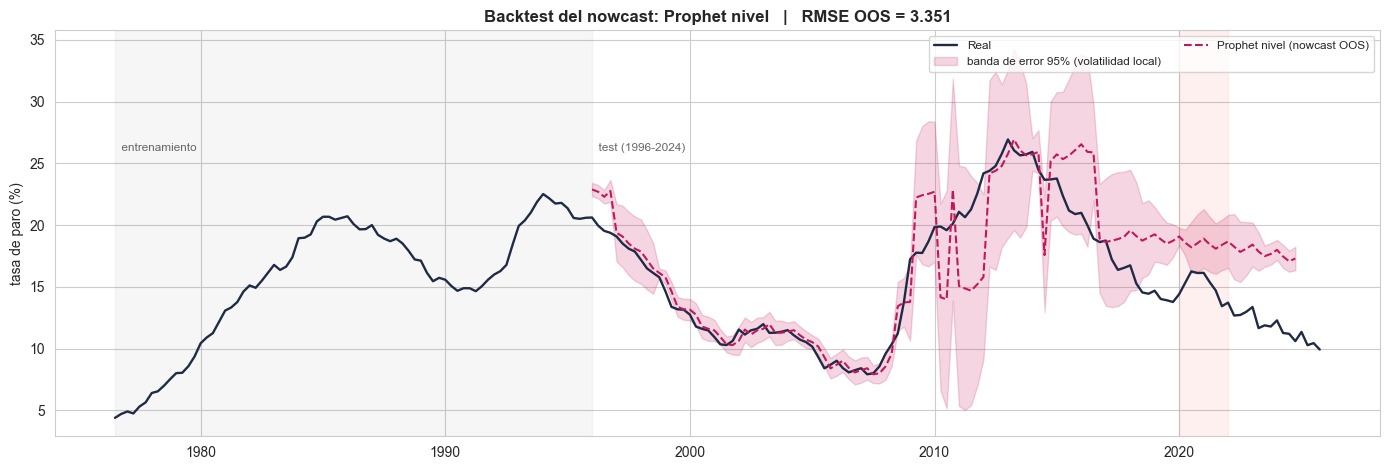

In [14]:
plot_backtest(preds_nivel, "Prophet nivel", C["nivel"])

**Lectura de la forma en nivel.** La búsqueda exhaustiva sobre la forma en nivel selecciona una tendencia casi rígida (`changepoint_prior_scale` de 0.0018) y el modelo fracasa: RMSE global de 5.750 y de 3.351 en el nowcast, muy por encima del paseo aleatorio (skill de -3.282) y del ARIMA. El diagnóstico train-test lo confirma como un problema de especificación, no de sobreajuste: el error en muestra (4.995) es incluso mayor que el de test del nowcast, un gap negativo que indica que el modelo ni siquiera ajusta bien el entrenamiento. La causa es estructural: sin componente autorregresivo, Prophet ancla el pronóstico a una tendencia extrapolada y, en una validación previa a 1996 de tramo suave, la búsqueda premia la rigidez, que resulta catastrófica en el test volátil. La forma en nivel, la natural de Prophet, no es viable para esta serie.

## 5. Forma en diferencia reconstruida (mejora metodológica)

Prophet modela el cambio intertrimestral de la tasa y el pronóstico se reconstruye acumulando desde el
último valor observado, lo que ancla el modelo. Se ejecuta la misma búsqueda exhaustiva. El resultado
se guarda como `prophet_diff1`.

In [15]:
est_diff1 = buscar_hp("diff1")
HP_DIFF1 = est_diff1.best_params
print("mejores HP (diff1):", {k: (round(v, 4) if isinstance(v, float) else v) for k, v in HP_DIFF1.items()})
tabla_trials(est_diff1)

mejores HP (diff1): {'fourier': 2, 'cps': 0.0031, 'cr': 0.8047, 'n_cp': 25, 'hps': 0.2713, 'sps': 4.4766}


,rmse_val,cps,cr,n_cp,hps,fourier
0,2.1289,0.0031,0.8047,25,0.2713,2
1,2.1300,0.0029,0.8033,26,0.2467,2
2,2.1319,0.0034,0.8144,26,0.1597,1
3,2.1334,0.0023,0.8397,23,0.3998,2
4,2.1342,0.0027,0.9179,14,0.3628,1
5,2.1348,0.0052,0.8185,27,0.1838,2
6,2.1353,0.0036,0.8047,27,0.1152,1
7,2.1382,0.0018,0.8145,25,0.2814,2
8,2.1394,0.0553,0.9417,35,0.0886,1
9,2.1396,0.0479,0.8648,31,0.0921,1


In [16]:
preds_diff1 = backtest("diff1", HP_DIFF1)
met_diff1 = metricas_desde_preds(preds_diff1, RMSE_RW, RMSE_AR)
met_diff1["referencia_rw"] = {str(h): RMSE_RW[h] for h in HORIZONTES}
met_diff1["benchmark_arima"] = {str(h): RMSE_AR[h] for h in HORIZONTES}
met_diff1["hiperparametros"] = {k: (round(v, 5) if isinstance(v, float) else v) for k, v in HP_DIFF1.items()}
guardar("prophet_diff1", preds_diff1, met_diff1)
tabla_horizontes(met_diff1)

23:07:12 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:07:12 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:07:12 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:07:12 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:07:13 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:07:13 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:07:13 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:07:13 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:07:14 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:07:14 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:07:14 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:07:15 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
23:07:15 - cmdstanpy - ERROR

[diff1] guardas de estabilidad activadas: 0/116


,rmse,mae,skill_vs_rw,skill_vs_arima,covid_rmse
horizonte,,,,,
0,0.7047,0.5037,0.099,-0.344,0.9024
1,1.2913,0.9252,0.029,-0.304,1.4740
2,1.8230,1.3446,-0.026,-0.289,1.8113
3,2.3402,1.7323,-0.061,-0.308,2.1185
4,2.8934,2.1617,-0.068,-0.261,2.4127


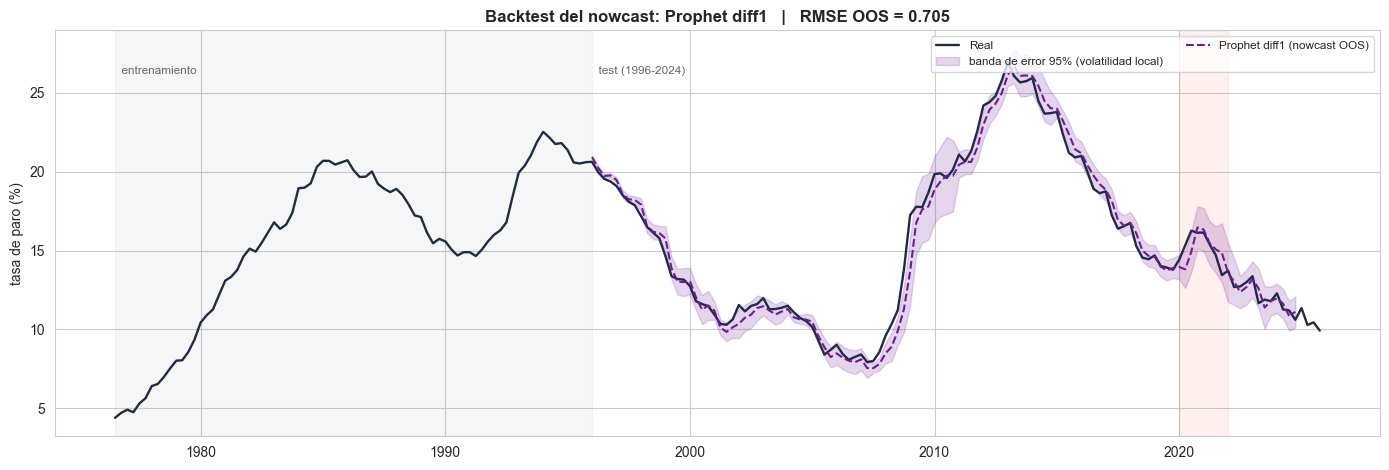

In [17]:
plot_backtest(preds_diff1, "Prophet diff1", C["diff1"])

**Lectura de la forma en diferencia.** Modelar el cambio intertrimestral y reconstruir el nivel acumulando desde el último valor observado transforma el resultado: el RMSE global cae de 5.750 a 1.967 y el del nowcast a 0.705, que **bate al paseo aleatorio** (skill +0.099). El mecanismo es el anclaje: al integrar la diferencia, el pronóstico parte del último dato real en lugar de una tendencia extrapolada, que es justo el componente autorregresivo que Prophet no tiene. La búsqueda elige aquí una tendencia muy rígida (`changepoint_prior_scale` de 0.0031), coherente con que la diferencia es estacionaria y apenas arrastra tendencia propia. El gap train-test es pequeño (0.611 en muestra frente a 0.705 en nowcast), señal de buena generalización. Aun así, la forma en diferencia no bate al ARIMA (skill de -0.344 a -0.261 por horizonte), que modela de forma nativa la estructura autorregresiva que aquí se reconstruye a mano.

## 6. Comparativa de las dos formas y stress-test COVID

La comparación entre la forma en nivel y la forma en diferencia es uno de los resultados del cuaderno:
muestra cuánto pesa, para una serie persistente, la forma en que Prophet modela la serie frente a sus
hiperparámetros. Se enfrentan además al suelo y al benchmark.

In [18]:
def fila_resumen(nombre, preds):
    """Fila comparativa: RMSE por horizonte, global y COVID de un modelo."""
    f = {"modelo": nombre}
    err = preds["y_real"] - preds["y_pred"]
    for h in HORIZONTES:
        f[f"rmse_h{h}"] = round(_rmse(err[preds["horizonte"] == h].to_numpy()), 3)
    f["rmse_global"] = round(_rmse(err.to_numpy()), 3)
    covid = err[preds["fecha"].astype(str).str.match(r"20(20|21)Q")]
    f["rmse_covid"] = round(_rmse(covid.to_numpy()), 3)
    return f


resumen = pd.DataFrame([fila_resumen("Random Walk", preds_rw), fila_resumen("ARIMA", preds_ar),
                        fila_resumen("Prophet nivel", preds_nivel),
                        fila_resumen("Prophet diff1", preds_diff1)]).set_index("modelo")
resumen

,rmse_h0,rmse_h1,rmse_h2,rmse_h3,rmse_h4,rmse_global,rmse_covid
modelo,,,,,,,
Random Walk,0.783,1.330,1.776,2.205,2.709,1.883,1.501
ARIMA,0.524,0.990,1.414,1.790,2.295,1.531,2.288
Prophet nivel,3.351,5.051,5.861,6.471,7.234,5.750,3.578
Prophet diff1,0.705,1.291,1.823,2.340,2.893,1.967,1.821


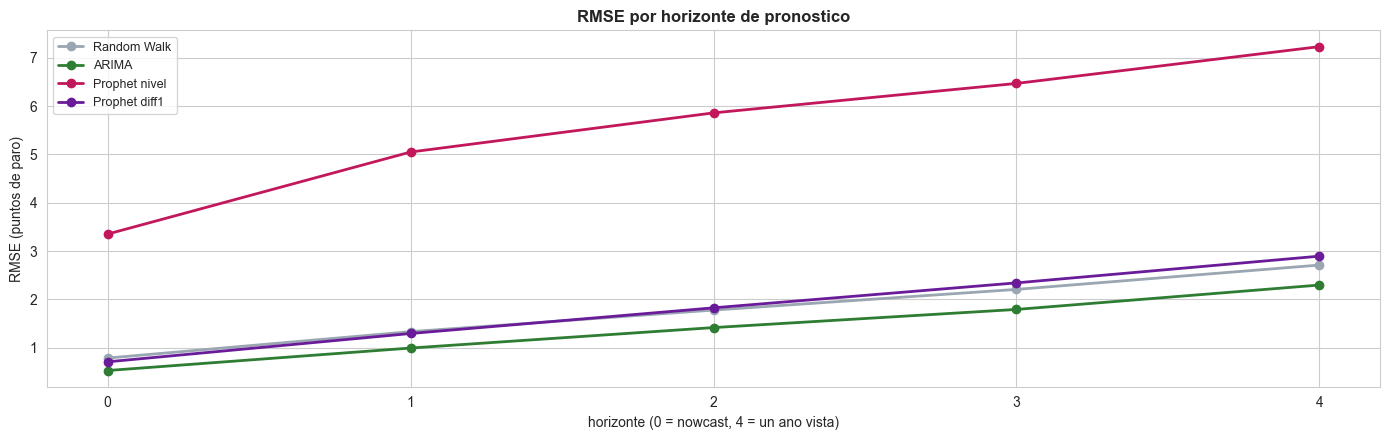

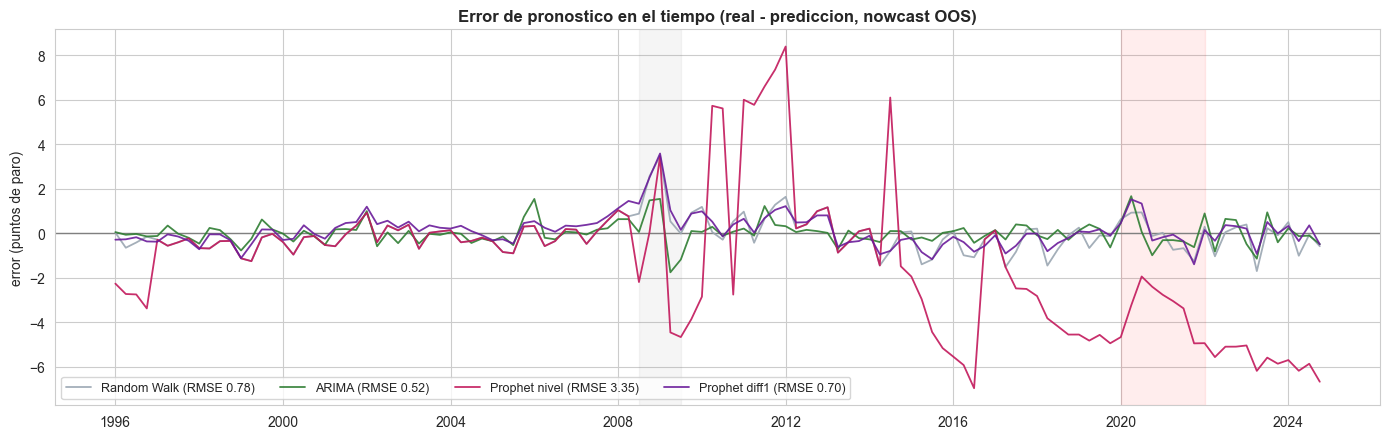

In [19]:
# RMSE por horizonte (comparacion directa) y error en el tiempo (vista de conjunto, sin sobreajuste)
_met = {k: json.load(open(RUTA_RESULTADOS / f"metricas_{k}.json", encoding="utf-8"))
        for k in ["random_walk", "arima", "prophet_nivel", "prophet_diff1"]}
plot_rmse_horizonte([("Random Walk", _met["random_walk"], C["rw"]), ("ARIMA", _met["arima"], C["arima"]),
                     ("Prophet nivel", _met["prophet_nivel"], C["nivel"]), ("Prophet diff1", _met["prophet_diff1"], C["diff1"])])

plot_errores([("Random Walk", preds_rw, C["rw"]), ("ARIMA", preds_ar, C["arima"]),
              ("Prophet nivel", preds_nivel, C["nivel"]), ("Prophet diff1", preds_diff1, C["diff1"])])

**Lectura de la comparativa.** El resultado central del cuaderno es que, para una serie tan persistente, **la forma en que Prophet modela la serie pesa más que sus hiperparámetros**: con la misma búsqueda exhaustiva, la forma en nivel da un RMSE global de 5.750 y la forma en diferencia de 1.967, casi tres veces mejor. La forma en diferencia queda a la altura del suelo, al que bate en el nowcast (0.705 frente a 0.783), pero ninguna de las dos supera al benchmark ARIMA (1.531). En el stress-test COVID el patrón se mantiene: la forma en diferencia se degrada de manera contenida (RMSE COVID de 0.902 a 2.413 por horizonte) mientras la forma en nivel se dispara. Para el cuaderno de ensamblaje se conserva la forma en diferencia, que aporta una descomposición estructural distinta de la del econométrico y errores con potencial de baja correlación.

## 7. Componentes y evolución esperada

Descomposición de Prophet (tendencia con changepoints y, si la hubiera, estacionalidad) y proyección de
la evolución esperada del paro con bandas de confianza, usando la mejor forma sobre la muestra completa.

forma mostrada: diff1


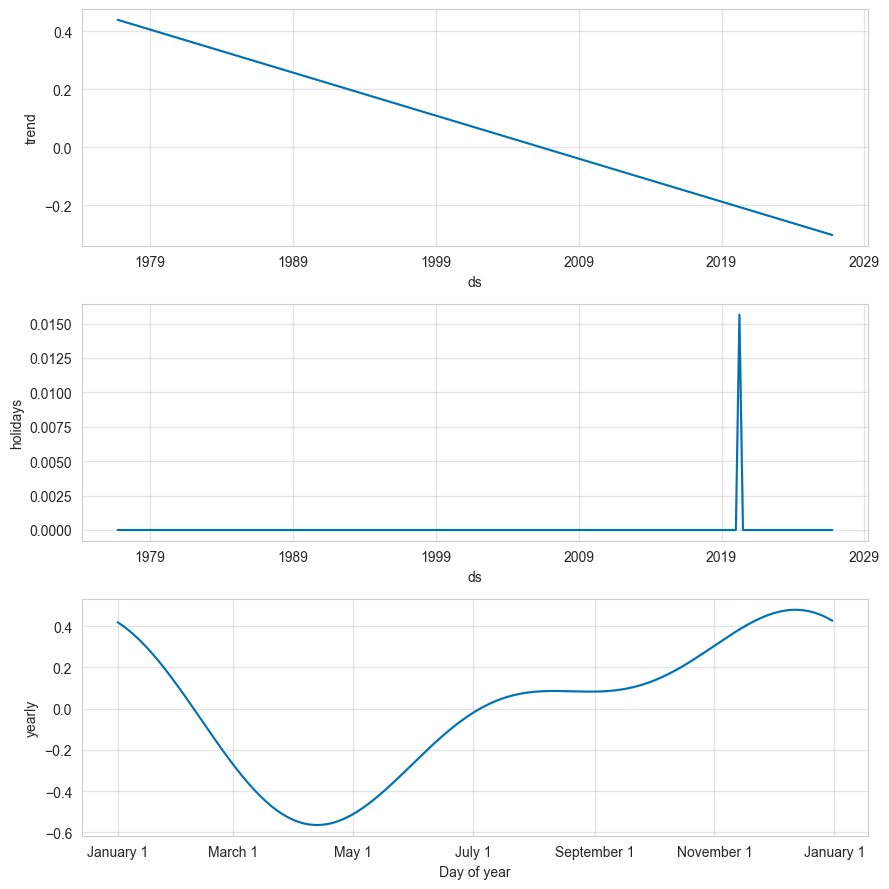

In [20]:
# Mejor forma por RMSE global, ajustada sobre la muestra completa para la vista de componentes/forecast
mejor_forma = "diff1" if met_diff1["global"]["rmse"] <= met_nivel["global"]["rmse"] else "nivel"
HP_MEJOR = HP_DIFF1 if mejor_forma == "diff1" else HP_NIVEL
serie = construir_serie(mejor_forma)
sdf = pd.DataFrame({"ds": fechas, "y": serie}).dropna()
m_full = fit_prophet(sdf, HP_MEJOR)
fc_full = m_full.predict(m_full.make_future_dataframe(periods=4, freq="QS"))
print(f"forma mostrada: {mejor_forma}")
fig = m_full.plot_components(fc_full)
plt.tight_layout(); plt.show()

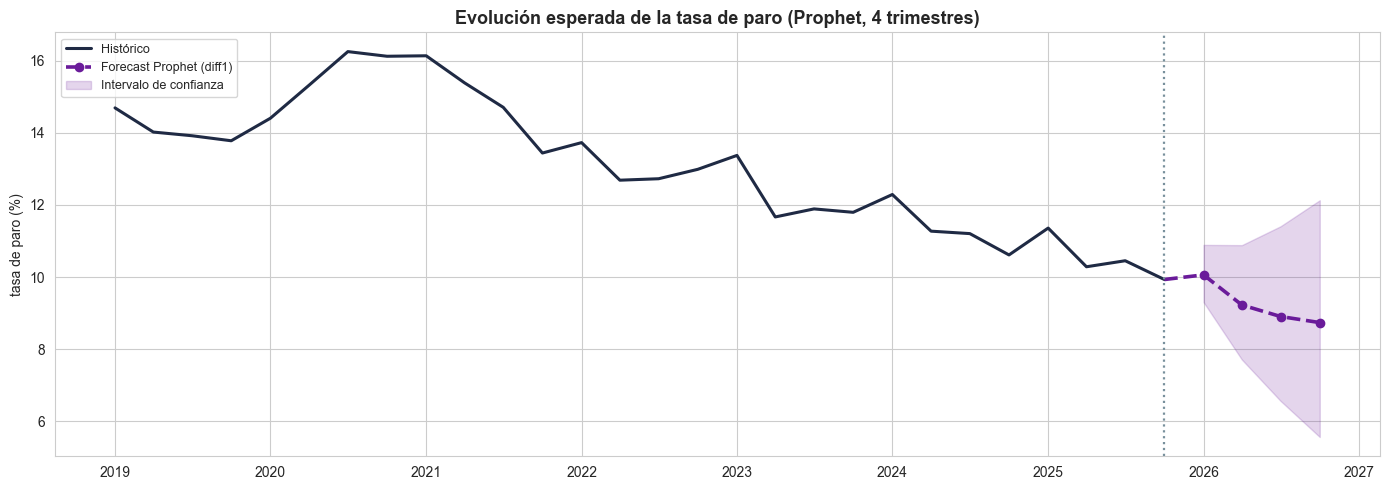

,trimestre,forecast,ic_inf,ic_sup
0,2026Q1,10.06,9.30,10.89
1,2026Q2,9.23,7.71,10.89
2,2026Q3,8.90,6.56,11.41
3,2026Q4,8.74,5.56,12.13


In [21]:
H = 4
idx_fut = pd.period_range(fechas.iloc[-1].to_period("Q") + 1, periods=H, freq="Q").to_timestamp()
cola_fc = fc_full.tail(H)
if mejor_forma == "diff1":                               # reconstruir nivel acumulando el cambio
    media = float(y.iloc[-1]) + np.cumsum(cola_fc["yhat"].to_numpy())
    lo = float(y.iloc[-1]) + np.cumsum(cola_fc["yhat_lower"].to_numpy())
    hi = float(y.iloc[-1]) + np.cumsum(cola_fc["yhat_upper"].to_numpy())
else:
    media, lo, hi = cola_fc["yhat"].to_numpy(), cola_fc["yhat_lower"].to_numpy(), cola_fc["yhat_upper"].to_numpy()

fig, ax = plt.subplots(figsize=(14, 5))
cola = y.iloc[-28:]
ax.plot(fechas.iloc[-28:], cola.values, color=C["real"], lw=2.2, label="Histórico")
ax.plot([fechas.iloc[-1], idx_fut[0]], [y.iloc[-1], media[0]], color=C["diff1"], lw=2.6, ls="--")
ax.plot(idx_fut, media, color=C["diff1"], lw=2.6, ls="--", marker="o", label=f"Forecast Prophet ({mejor_forma})")
ax.fill_between(idx_fut, lo, hi, color=C["band"], alpha=0.18, label="Intervalo de confianza")
ax.axvline(fechas.iloc[-1], color=C["corte"], ls=":", lw=1.6)
ax.set_title("Evolución esperada de la tasa de paro (Prophet, 4 trimestres)", fontsize=13, fontweight="bold")
ax.set_ylabel("tasa de paro (%)"); ax.legend(fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()

pd.DataFrame({"trimestre": [str(p) for p in pd.period_range(fechas.iloc[-1].to_period("Q") + 1, periods=H, freq="Q")],
              "forecast": media.round(2), "ic_inf": lo.round(2), "ic_sup": hi.round(2)})

In [22]:
pd.DataFrame({'trimestre': ["2026Q1", "2026Q2", "2026Q3", "2026Q4"],
              'forecast': np.round(media, 2),
              'IC_inf': np.round(lo, 2), 'IC_sup': np.round(hi, 2)}
            ).to_csv(RUTA_RESULTADOS / 'proyeccion_futura_prophet.csv', index=False)
print('guardado: proyeccion_futura_prophet.csv')

guardado: proyeccion_futura_prophet.csv


## 8. Cierre

Quedan guardados en `Resultados/` los dos pares de la familia Prophet, `prophet_nivel` y `prophet_diff1`, para el cuaderno de comparación y ensamblaje. Cada fichero de métricas incluye RMSE y MAE por horizonte, global y subperiodo COVID, el skill frente al paseo aleatorio y al ARIMA, los hiperparámetros elegidos por la búsqueda y el diagnóstico de error en entrenamiento frente a test.

**Checkpoint de honestidad.**

- **Hecho.** Dos formas de Prophet, en nivel y en diferencia reconstruida, optimizadas con búsqueda exhaustiva y evaluadas en 116 folds del expanding window.
- **Hallazgo.** La forma en nivel, la natural de Prophet, fracasa (RMSE global 5.750) por falta de anclaje autorregresivo. La forma en diferencia (1.967) lo resuelve y bate al suelo en el nowcast, pero ninguna bate al benchmark ARIMA. Para una serie persistente, la forma de la serie pesa más que los hiperparámetros.
- **Diagnóstico train-test.** `prophet_nivel` tiene gap negativo (mala especificación, no sobreajuste); `prophet_diff1` tiene gap pequeño (generaliza bien).
- **Limitaciones declaradas.** La búsqueda en nivel es degenerada por el régimen suave del tramo de validación previo al test. Los regresores macro no entran en el modelo principal por no conocerse a futuro y no aportar sobre el univariante (sección 5).
- Para el ensamblaje se usa `prophet_diff1`.